# Calidad de las bioactividades y filtro de promiscuidad

Composición de las bioactividades por tag y por fuente, y **filtro de
promiscuidad química**: 30 compuestos de `MW < 150 Da` concentran 104 075
relaciones de subestructura, el 12 % de la capa, y hoy ninguna está filtrada
(S3 Fig del paper 2016).

**Decidido (CONVENCIONES.md §10): el filtro se aplica.** Este notebook produce
`03_compuestos_promiscuos.csv`, que `huerfanas/` consume vía
`tdr.compuestos_promiscuos()` antes de construir cualquier semilla. Por eso hay
que correrlo **antes** del paso 5 del orden de trabajo.

Origen: el filtro de promiscuidad de la versión v3 (fuera de este repositorio).

Salidas: `03_bioactividades_por_tag.csv`, `03_promiscuidad_por_compuesto.csv`,
`03_compuestos_promiscuos.csv`, `03_curva_filtrado.csv`, `03_impacto_filtro.csv`.

## Imports

In [1]:
import sys, os
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(_v, "1")          # antes de numpy: un hilo por proceso

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

from pathlib import Path
# raiz del repositorio: se busca hacia arriba la carpeta que tiene DB/,
# asi el notebook corre desde donde sea que se haya clonado
RAIZ = Path.cwd()
while not (RAIZ / "DB").is_dir() and RAIZ != RAIZ.parent:
    RAIZ = RAIZ.parent
sys.path.insert(0, str(RAIZ / "comun"))
sys.path.insert(0, str(RAIZ / "analiceDB"))
%load_ext autoreload
%autoreload 2
import tdr, nucleo as nf
import funciones_analice as fa              # el .py de esta carpeta
import figuras as F                        # comun/figuras.py: las figuras, desde las tablas

SALIDAS = tdr.out("analiceDB")
FIGURAS = SALIDAS / "figuras"
NB      = "03"                             # numero de este notebook: prefija todo lo que genere
n_core  = tdr.N_CORE_DEFAULT                # 20 salvo TDR_NCORE

plt = tdr.estilo()
SALIDAS

PosixPath('/data1/TDR-2025/TDR_v7/GW-AI-course/TDR-GW-AI-course/resultados/analiceDB_out')

## Datos

In [2]:
datos = tdr.cargar_db(anotaciones=False, cluster_consistent=False)
# Las relaciones de subestructura crudas: la capa guardada ya está clusterizada
# y no conserva el conteo de superestructuras por molécula.
# exigir_mapa: sin TDR_MAPEOS la lista de promiscuos sale falsa sin que nada falle
sub, comp = fa.cargar_subestructuras_crudas(exigir_mapa=True)
len(datos.bioact), len(sub), len(comp)

· 00_specie_target


· 03_bioactivities_target_compound


(1983780, 460906, 865120)

## Acondicionamiento

In [3]:
tags = fa.composicion_bioactividades(datos)
print(f"{len(sub)} relaciones de subestructura mapeadas a compuestos")
print(f"criterio: MW < {tdr.MW_PROMISCUIDAD} Da y N_parentales > {tdr.N_PARENTALES_PROMISCUIDAD}")
tags.head(12)

460906 relaciones de subestructura mapeadas a compuestos
criterio: MW < 150 Da y N_parentales > 100


,activity_tag,cluster_consistent,n,pct
0,1,1,1628322,82.081783
1,2,1,248457,12.524423
2,3,1,101885,5.135902
3,0,1,4919,0.247961
4,2,0,88,0.004436
5,3,0,88,0.004436
6,1,0,19,0.000958
7,0,0,2,0.000101


## Corrida

In [4]:
# celda de corrida: el ciclo se lee aca
por_compuesto, promiscuos, impacto = fa.promiscuidad_subestructural(sub, comp)
curva = fa.curva_filtrado(por_compuesto, sub)

tags.to_csv(SALIDAS / f"{NB}_bioactividades_por_tag.csv", index=False)
por_compuesto.to_csv(SALIDAS / f"{NB}_promiscuidad_por_compuesto.csv", index=False)
promiscuos.to_csv(SALIDAS / f"{NB}_compuestos_promiscuos.csv", index=False)  # <- lo lee huerfanas/
curva.to_csv(SALIDAS / f"{NB}_curva_filtrado.csv", index=False)
impacto.to_csv(SALIDAS / f"{NB}_impacto_filtro.csv", index=False)
fa.escribir_meta(SALIDAS, NB, notebook="03_calidad_bioactividades.ipynb",
                 params={"mw_max": tdr.MW_PROMISCUIDAD,
                         "n_parentales_min": tdr.N_PARENTALES_PROMISCUIDAD},
                 aplica_filtro=True, consumido_por="huerfanas/")

  meta -> /data1/TDR-2025/TDR_v7/GW-AI-course/TDR-GW-AI-course/resultados/analiceDB_out/03_meta.json


{'notebook': '03_calidad_bioactividades.ipynb',
 'nb': '03',
 'fecha': '2026-09-10 10:31',
 'params': {'mw_max': 150, 'n_parentales_min': 100},
 'n_core': None,
 'tablas_db': {'00_specie_target.csv': '2026-09-08',
  '01_clusters_fingerprint.csv': '2026-09-08',
  '01_edges_clusters_fingerprint.part00.csv.gz': '2026-09-08',
  '01_edges_clusters_fingerprint.part01.csv.gz': '2026-09-08',
  '02_clusters_subestructure.csv': '2026-09-08',
  '02_edges_clusters_subestructure.csv': '2026-09-08',
  '03_bioactivities_organism_compound.csv': '2026-09-08',
  '03_bioactivities_target_compound.csv': '2026-09-08',
  '04a_interpro.csv': '2026-09-08',
  '04b_orthomcl.csv': '2026-09-08'},
 'python': '3.12.11',
 'pandas': '3.0.5',
 'aplica_filtro': True,
 'consumido_por': 'huerfanas/'}

# Resultados

Desde acá no se toca la base: cada figura lee sus tablas de `resultados/` y la
dibuja `F.dibujar(...)` (las funciones están en `figuras_analice.py`). Para
regenerarlas sin volver a pagar la corrida alcanza con la celda de imports y esta
sección, o, desde la raíz del repositorio:

    python comun/figuras.py analiceDB

In [5]:
tags          = pd.read_csv(SALIDAS / f"{NB}_bioactividades_por_tag.csv")
por_compuesto = pd.read_csv(SALIDAS / f"{NB}_promiscuidad_por_compuesto.csv")
promiscuos    = pd.read_csv(SALIDAS / f"{NB}_compuestos_promiscuos.csv")
curva         = pd.read_csv(SALIDAS / f"{NB}_curva_filtrado.csv")
impacto       = pd.read_csv(SALIDAS / f"{NB}_impacto_filtro.csv")
impacto.T

,0
criterio,MW < 150 y N_parentales > 100
compuestos_filtrados,7
pct_compuestos,0.008325
aristas_filtradas,7445
pct_aristas,1.615297
n_parentales_p99,25.0
mw_mediana_filtrados,116.131349


  figura -> /data1/TDR-2025/TDR_v7/GW-AI-course/TDR-GW-AI-course/resultados/analiceDB_out/figuras/03_f01_bioactividades_por_tag.pdf


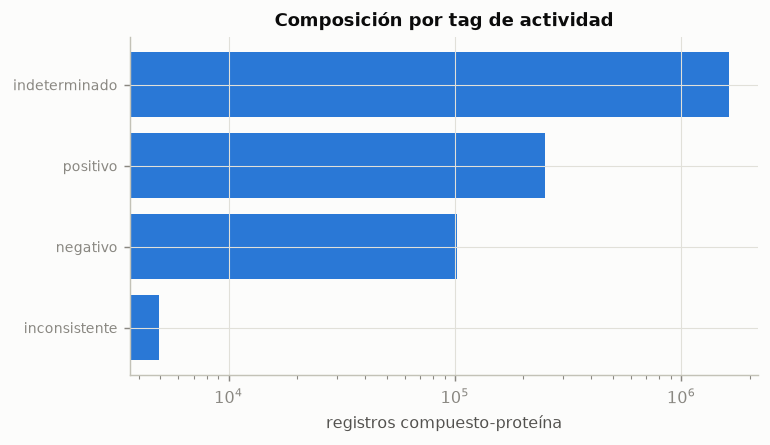

In [6]:
F.dibujar("03_f01_bioactividades_por_tag");

  figura -> /data1/TDR-2025/TDR_v7/GW-AI-course/TDR-GW-AI-course/resultados/analiceDB_out/figuras/03_f02_promiscuidad.pdf


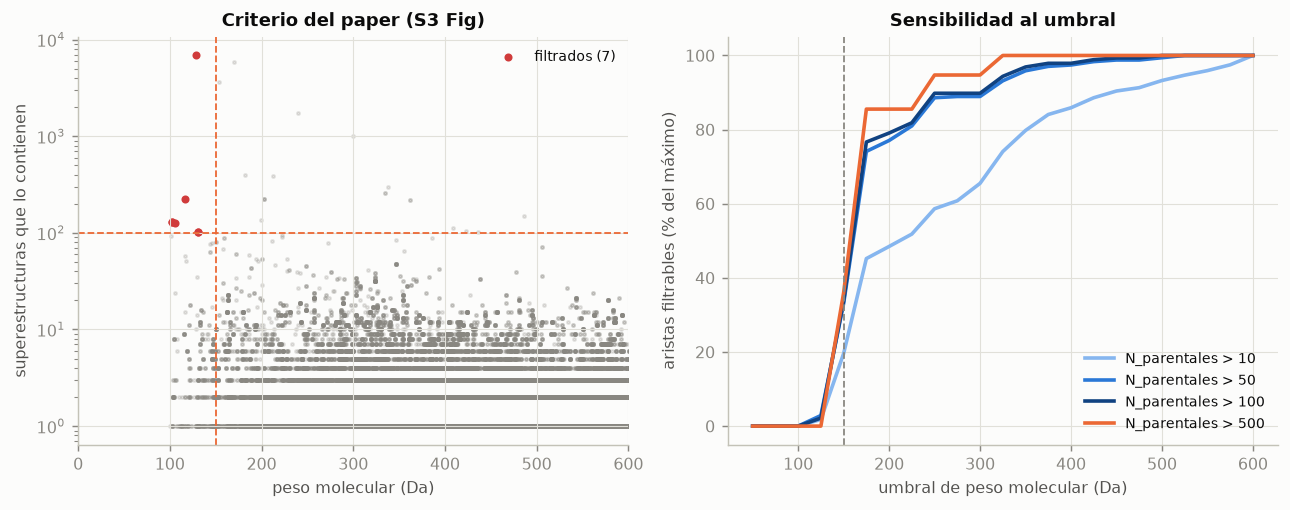

In [7]:
F.dibujar("03_f02_promiscuidad");

In [8]:
# Los compuestos que se van: es el resultado que condiciona todo lo que viene después
promiscuos.head(30)

,drug_id,n_parentales,molweight
0,276182,6863,128.062600
1,628901,223,116.131349
2,451642,129,102.115698
3,451642,129,102.115698
4,462414,127,106.078250
5,200190,103,131.142248
6,200190,103,131.142248
